In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler,OneHotEncoder
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import SelectKBest
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from collections import Counter
import matplotlib.pyplot as plt

In [ ]:
# Load the KDDCup99 dataset
print("Loading KDDCup99 dataset...")
kdd = fetch_openml(name='kddcup99', version=1, as_frame=True)
X = kdd.data
y = kdd.target

print(y)

Loading KDDCup99 dataset...
0         normal
1         normal
2         normal
3         normal
4         normal
           ...  
494015    normal
494016    normal
494017    normal
494018    normal
494019    normal
Name: label, Length: 494020, dtype: category
Categories (23, object): ['buffer_overflow', 'guess_passwd', 'loadmodule', 'neptune', ..., 'warezmaster',
                          'rootkit', 'spy', 'warezclient']


In [ ]:
# Encode labels (target variable)
print("Encoding labels...")
le = LabelEncoder()
y = le.fit_transform(y)

Encoding labels...


In [ ]:
# Select a subset of the data to reduce computation time
print("Selecting a subset of the data...")
X = X.sample(frac=0.1, random_state=42)
y = y[X.index]

Selecting a subset of the data...


In [ ]:
# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Preprocessing: One-hot encode categorical columns and scale numerical columns
print("Preprocessing data...")
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Apply preprocessing
X_processed = preprocessor.fit_transform(X)

Preprocessing data...


In [ ]:
# Perform MRMR feature selection
print("Performing MRMR feature selection...")
mi_scores = mutual_info_classif(X_processed, y)
selected_features = SelectKBest(lambda X, y: mi_scores, k=20).fit_transform(X_processed, y)

Performing MRMR feature selection...


In [ ]:
# Split the dataset into training and testing sets
print("Splitting dataset into training and testing sets...")
X_train, X_test, y_train, y_test = train_test_split(selected_features, y, test_size=0.3, random_state=42)

Splitting dataset into training and testing sets...


In [ ]:
# Check class distribution
print("Class distribution before SMOTE:", Counter(y_train))

# Remove rare classes (classes with fewer than 5 samples)
min_samples = 5
rare_classes = [cls for cls, count in Counter(y_train).items() if count < min_samples]
if rare_classes:
    print("Removing rare classes:", rare_classes)
    mask = np.isin(y_train, rare_classes, invert=True)
    X_train = X_train[mask]
    y_train = y_train[mask]

# Check class distribution after removing rare classes
print("Class distribution after removing rare classes:", Counter(y_train))

Class distribution before SMOTE: Counter({18: 19762, 9: 7403, 11: 6833, 0: 151, 17: 89, 5: 87, 21: 78, 15: 72, 20: 67, 14: 15, 10: 15, 1: 3, 3: 2, 6: 1, 4: 1, 16: 1, 7: 1})
Removing rare classes: [1, 6, 3, 4, 16, 7]
Class distribution after removing rare classes: Counter({18: 19762, 9: 7403, 11: 6833, 0: 151, 17: 89, 5: 87, 21: 78, 15: 72, 20: 67, 14: 15, 10: 15})


In [ ]:
# Adjust SMOTE's k parameter based on the smallest class size
min_class_size = min(Counter(y_train).values())
smote_k = min(5, min_class_size - 1)  # Ensure k is less than the smallest class size
if smote_k < 1:
    smote_k = 1  # Ensure k is at least 1

# Apply SMOTE to handle class imbalance
print("Applying SMOTE with k =", smote_k, "...")
smote = SMOTE(random_state=42, k_neighbors=smote_k)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Check class distribution after SMOTE
print("Class distribution after SMOTE:", Counter(y_train_smote))

Applying SMOTE with k = 5 ...
Class distribution after SMOTE: Counter({18: 19762, 9: 19762, 11: 19762, 20: 19762, 15: 19762, 17: 19762, 0: 19762, 21: 19762, 5: 19762, 14: 19762, 10: 19762})


In [ ]:
# Function to evaluate models
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    return accuracy, precision, recall, f1

In [ ]:
# Train and evaluate SVM
print("Training SVM...")
svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train_smote, y_train_smote)
svm_accuracy, svm_precision, svm_recall, svm_f1 = evaluate_model(svm, X_test, y_test)
print("SVM Classification Report:")
print(classification_report(y_test, svm.predict(X_test), zero_division=0))

Training SVM...
SVM Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96        62
           4       0.00      0.00      0.00         1
           5       0.73      0.78      0.75        41
           9       1.00      1.00      1.00      3183
          10       0.19      0.43      0.26         7
          11       1.00      0.90      0.95      2879
          12       0.00      0.00      0.00         1
          14       0.17      1.00      0.29         3
          15       1.00      0.97      0.98        31
          17       1.00      0.91      0.95        55
          18       1.00      1.00      1.00      8494
          20       0.96      1.00      0.98        26
          21       0.13      0.97      0.23        38

    accuracy                           0.98     14821
   macro avg       0.62      0.77      0.64     14821
weighted avg       1.00      0.98      0.99     14821



In [ ]:
print("SVM Accuracy:", svm_accuracy*100)
print("SVM Precision:", svm_precision*100)
print("SVM Recall:", svm_recall*100)
print("SVM F1 Score:", svm_f1)

SVM Accuracy: 97.9893394507793
SVM Precision: 99.54532187915015
SVM Recall: 97.9893394507793
SVM F1 Score: 0.9862951088524831


In [ ]:
# Train and evaluate Decision Tree
print("Training Decision Tree...")
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_smote, y_train_smote)
dt_accuracy, dt_precision, dt_recall, dt_f1 = evaluate_model(dt, X_test, y_test)
print("Decision Tree Classification Report:")
print(classification_report(y_test, dt.predict(X_test), zero_division=0))

Training Decision Tree...
Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        62
           4       0.00      0.00      0.00         1
           5       0.95      0.98      0.96        41
           9       1.00      1.00      1.00      3183
          10       0.71      0.71      0.71         7
          11       1.00      1.00      1.00      2879
          12       0.00      0.00      0.00         1
          14       0.67      0.67      0.67         3
          15       0.85      0.94      0.89        31
          17       0.93      0.95      0.94        55
          18       1.00      1.00      1.00      8494
          20       1.00      1.00      1.00        26
          21       0.89      0.87      0.88        38

    accuracy                           1.00     14821
   macro avg       0.77      0.77      0.77     14821
weighted avg       1.00      1.00      1.00     14821



In [ ]:
print("Decision Tree Accuracy:", dt_accuracy*100)
print("Decision Tree Precision:", dt_precision*100)
print("Decision Tree Recall:", dt_recall*100)
print("Decision Tree F1 Score:", dt_f1)

Decision Tree Accuracy: 99.80433169151878
Decision Tree Precision: 99.7939257477838
Decision Tree Recall: 99.80433169151878
Decision Tree F1 Score: 0.9979850818488543


In [ ]:
# Train and evaluate KNN
print("Training KNN...")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_smote, y_train_smote)
knn_accuracy, knn_precision, knn_recall, knn_f1 = evaluate_model(knn, X_test, y_test)
print("KNN Classification Report:")
print(classification_report(y_test, knn.predict(X_test), zero_division=0))

Training KNN...
KNN Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        62
           4       0.00      0.00      0.00         1
           5       0.81      0.93      0.86        41
           9       1.00      1.00      1.00      3183
          10       0.60      0.86      0.71         7
          11       1.00      0.98      0.99      2879
          12       0.00      0.00      0.00         1
          14       0.20      1.00      0.33         3
          15       0.94      1.00      0.97        31
          17       0.98      0.89      0.93        55
          18       1.00      1.00      1.00      8494
          20       0.96      1.00      0.98        26
          21       0.58      0.84      0.69        38

    accuracy                           1.00     14821
   macro avg       0.70      0.81      0.73     14821
weighted avg       1.00      1.00      1.00     14821



In [ ]:
print("KNN Accuracy:", knn_accuracy*100)
print("KNN Precision:", knn_precision*100)
print("KNN Recall:", knn_recall*100)
print("KNN F1 Score:", knn_f1)

KNN Accuracy: 99.5749274677822
KNN Precision: 99.68960989406445
KNN Recall: 99.5749274677822
KNN F1 Score: 0.9961683056771111


In [ ]:
# Compare models using a bar plot
models = ['SVM', 'Decision Tree', 'KNN']
accuracy_scores = [svm_accuracy, dt_accuracy, knn_accuracy]
precision_scores = [svm_precision, dt_precision, knn_precision]
recall_scores = [svm_recall, dt_recall, knn_recall]
f1_scores = [svm_f1, dt_f1, knn_f1]

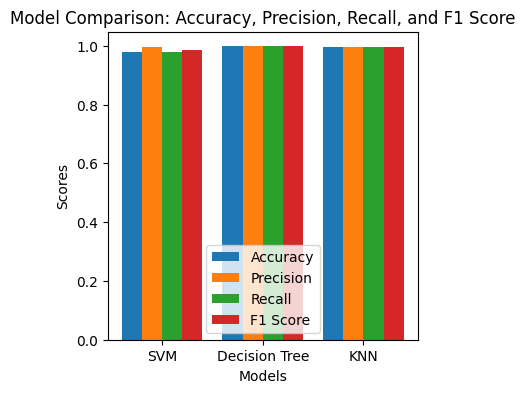

In [ ]:
x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(4,4))
plt.bar(x - 1.5 * width, accuracy_scores, width, label='Accuracy')
plt.bar(x - 0.5 * width, precision_scores, width, label='Precision')
plt.bar(x + 0.5 * width, recall_scores, width, label='Recall')
plt.bar(x + 1.5 * width, f1_scores, width, label='F1 Score')

plt.xlabel('Models')
plt.ylabel('Scores')
plt.title('Model Comparison: Accuracy, Precision, Recall, and F1 Score')
plt.xticks(x, models)
plt.legend()
plt.show()

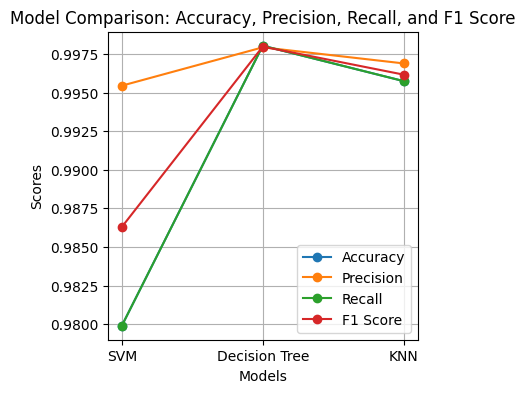

In [ ]:
# Line plot for model comparison
plt.figure(figsize=(4,4))

# Plot lines for each metric
plt.plot(models, accuracy_scores, marker='o', label='Accuracy')
plt.plot(models, precision_scores, marker='o', label='Precision')
plt.plot(models, recall_scores, marker='o', label='Recall')
plt.plot(models, f1_scores, marker='o', label='F1 Score')

# Add labels, title, and legend
plt.xlabel('Models')
plt.ylabel('Scores')
plt.title('Model Comparison: Accuracy, Precision, Recall, and F1 Score')
plt.legend()
plt.grid(True)  # Add grid for better readability

plt.show()

In [ ]:
# DataFrame to display model metrics in a table
import pandas as pd


data = {
    'Model': models,
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1 Score': f1_scores
}

#  dictionary to a DataFrame
metrics_df = pd.DataFrame(data)

# Print the table
print("\nModel Evaluation Metrics:")
print(metrics_df.to_string(index=False))


Model Evaluation Metrics:
        Model  Accuracy  Precision   Recall  F1 Score
          SVM  0.979893   0.995453 0.979893  0.986295
Decision Tree  0.998043   0.997939 0.998043  0.997985
          KNN  0.995749   0.996896 0.995749  0.996168


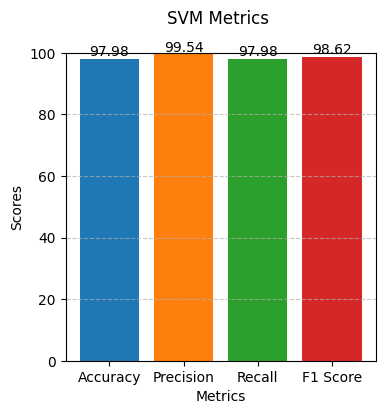

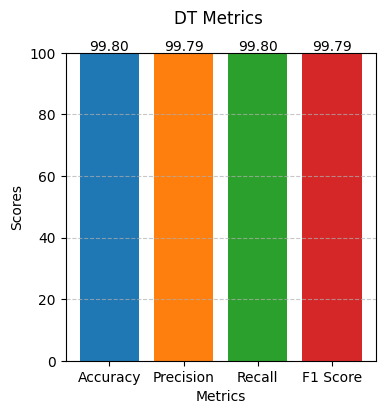

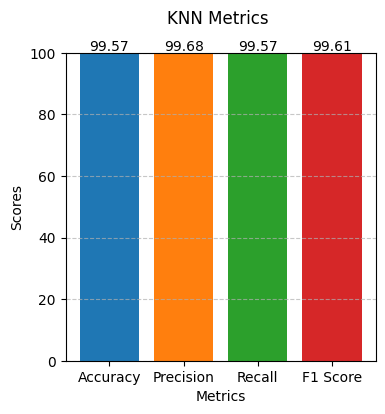

In [ ]:
import matplotlib.pyplot as plt

# Define the metric names
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

# Sample scores for each model (values are between 0 and 1)
svm_scores = [97.98, 99.54, 97.98, 98.62]
dt_scores  = [99.80, 99.79, 99.80, 99.79]
knn_scores = [99.57, 99.68, 99.57, 99.61]

# Create a dictionary for easier iteration
models_data = {
    "SVM": svm_scores,
    "DT": dt_scores,
    "KNN": knn_scores
}

# Create a bar graph for each model individually
for model_name, scores in models_data.items():
    plt.figure(figsize=(4, 4))
    bars = plt.bar(metrics, scores, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])

    # Add text labels above each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f'{height:.2f}',
            ha='center',
            va='bottom'
        )

    plt.ylim(0, 100)
    plt.xlabel("Metrics")
    plt.ylabel("Scores")
    plt.title(f"{model_name} Metrics \n")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


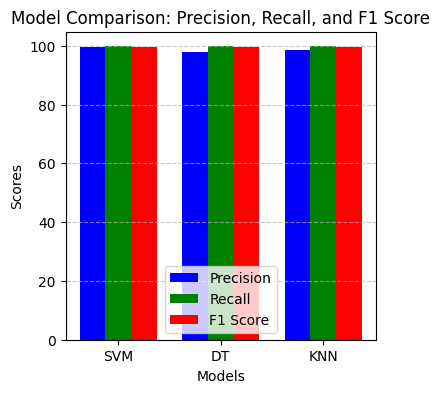

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data for the models
models = ['SVM', 'DT', 'KNN']
precision_scores = [99.54, 97.98, 98.62]
recall_scores    = [99.79, 99.80, 99.79]
f1_scores        = [99.68, 99.57, 99.61]

# Set positions of the bars on the x-axis
x = np.arange(len(models))  # the label locations
width = 0.25  # the width of the bars

# Create the figure and axis
fig, ax = plt.subplots(figsize=(4, 4))

# Plot bars for each metric
rects1 = ax.bar(x - width, precision_scores, width, label='Precision', color='blue')
rects2 = ax.bar(x, recall_scores, width, label='Recall', color='green')
rects3 = ax.bar(x + width, f1_scores, width, label='F1 Score', color='red')

# Add labels, title, and custom x-axis tick labels, etc.
ax.set_xlabel('Models')
ax.set_ylabel('Scores')
ax.set_title('Model Comparison: Precision, Recall, and F1 Score')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# Optionally, add grid lines for better readability
ax.grid(True, axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()


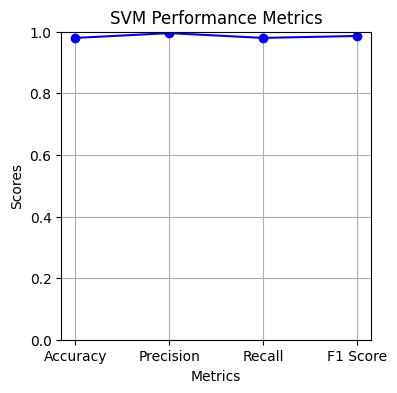

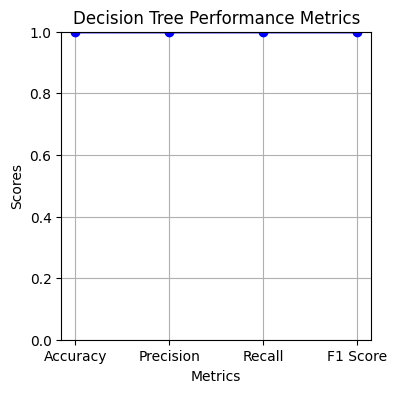

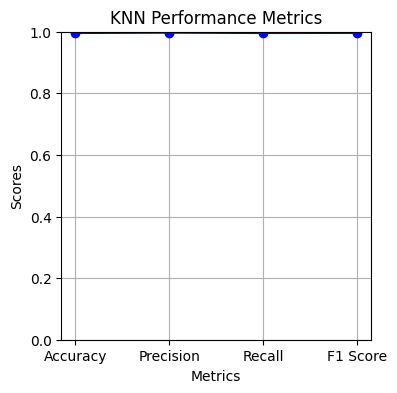

In [ ]:
# Function to plot individual graphs for each model
def plot_model_metrics(model_name, accuracy, precision, recall, f1):
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
    scores = [accuracy, precision, recall, f1]

    plt.figure(figsize=(4,4))
    plt.plot(metrics, scores, marker='o', linestyle='-', color='b')
    plt.title(f'{model_name} Performance Metrics')
    plt.xlabel('Metrics')
    plt.ylabel('Scores')
    plt.ylim(0, 1)  # Set y-axis limit between 0 and 1
    plt.grid(True)
    plt.show()

# Plot separate graphs for each model
plot_model_metrics('SVM', svm_accuracy, svm_precision, svm_recall, svm_f1)
plot_model_metrics('Decision Tree', dt_accuracy, dt_precision, dt_recall, dt_f1)
plot_model_metrics('KNN', knn_accuracy, knn_precision, knn_recall, knn_f1)

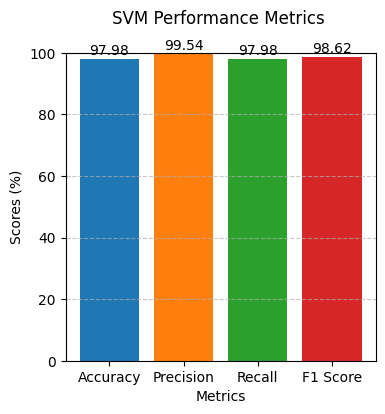

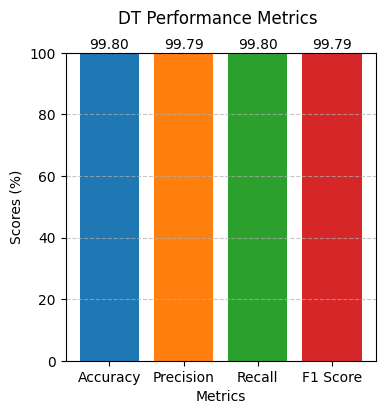

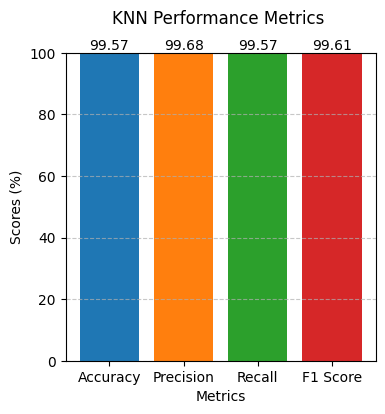

In [ ]:
import matplotlib.pyplot as plt

# Define the metric names
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

# Sample scores for each model (values are between 0 and 100)
svm_scores = [97.98, 99.54, 97.98, 98.62]
dt_scores  = [99.80, 99.79, 99.80, 99.79]
knn_scores = [99.57, 99.68, 99.57, 99.61]

# Create a dictionary for easier iteration
models_data = {
    "SVM": svm_scores,
    "DT": dt_scores,
    "KNN": knn_scores
}

# Create a bar graph for each model individually
for model_name, scores in models_data.items():
    plt.figure(figsize=(4,4))
    bars = plt.bar(metrics, scores, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])

    # Add text labels above each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.5,  # Adjusted for better visibility
            f'{height:.2f}',
            ha='center',
            va='bottom'
        )

    plt.ylim(0, 100)  # Scale from 0 to 100
    plt.xlabel("Metrics")
    plt.ylabel("Scores (%)")  # Indicate percentage
    plt.title(f"{model_name} Performance Metrics \n")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
